# Subtask 4 — Open Source Model Heatmap (Prompt 1–10)
Visualizes micro-F1 / overall score for the 10 open-source models across prompt IDs 1–10.

In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('../results/dev')

In [2]:
# Load all result files and parse model name, prompt_id, and overall_score
def load_scores(results_dir):
    data = []
    for file_path in results_dir.glob('*.json'):
        try:
            with open(file_path, 'r') as f:
                metrics = json.load(f)
            filename = file_path.stem
            if '_prompt_' in filename:
                model_name, prompt_part = filename.rsplit('_prompt_', 1)
                prompt_id = prompt_part
            else:
                model_name = filename
                prompt_id = 'unknown'
            data.append({
                'model': model_name,
                'prompt_id': prompt_id,
                'overall_score': metrics.get('overall_score', None),
            })
        except Exception as e:
            print(f'Error reading {file_path}: {e}')
    return pd.DataFrame(data)

df = load_scores(RESULTS_DIR)

In [3]:
# Filter to prompt IDs 1–10 only (excludes prompt_0, _11, _12, prefixed, twostep, etc.)
df['prompt_id'] = pd.to_numeric(df['prompt_id'], errors='coerce')
df = df.dropna(subset=['prompt_id'])
df['prompt_id'] = df['prompt_id'].astype(int)
df = df[df['prompt_id'].between(1, 10)]

print("Models found:", sorted(df['model'].unique()))
print("Prompt IDs:", sorted(df['prompt_id'].unique()))

Models found: ['BioMistral-BioMistral-7B', 'Echelon-AI-Med-Qwen2-7B', 'Qwen-Qwen3-32b', 'Qwen-Qwen3-8B', 'anthropic-claude-haiku-4-5', 'anthropic-claude-opus-4-5', 'anthropic-claude-opus-4-6', 'anthropic-claude-sonnet-4', 'anthropic-claude-sonnet-4-5', 'anthropic-claude-sonnet-4-6', 'deepseek-deepseek-chat-v3-0324', 'deepseek-deepseek-v3-2', 'google-gemini-2-0-flash-001', 'google-gemini-2-5-flash', 'google-gemini-2-5-flash-lite', 'google-gemini-2-5-flash-lite-preview-09-2025', 'google-gemini-2-5-pro', 'google-gemini-3-1-pro-preview', 'google-gemini-3-flash-preview', 'google-gemini-3-pro-preview', 'google-gemma-3-27b-it', 'google-medgemma-1-5-4b-it', 'google-medgemma-27b-text-it', 'google-medgemma-4b-it', 'khazarai-Bio-8B-it', 'meta-llama-Llama-3-1-8B-Instruct', 'meta-llama-llama-3-3-70b-instruct', 'meta-llama-llama-4-scout', 'minimax-minimax-m2-1', 'minimax-minimax-m2-5', 'moonshotai-kimi-k2-5', 'moonshotai-kimi-k2-thinking', 'nvidia-nemotron-3-nano-30b-a3b:free', 'openai-gpt-4-1', 'op

In [4]:
# --- Define model groups ---
closed_source_models = [
    'google-gemini-2-5-flash',
    'openai-gpt-4-1',
    'x-ai-grok-4-fast',
    'openai-gpt-5',
    'google-gemini-2-0-flash-001',
    'anthropic-claude-opus-4-5',
    'anthropic-claude-opus-4-6',
    'anthropic-claude-sonnet-4-5',
    'google-gemini-3-flash-preview',
    'anthropic-claude-sonnet-4',
    'x-ai-grok-4-1-fast',
    # 'nvidia-nemotron-3-nano-30b-a3b:free',
    # 'deepseek-deepseek-v3-2',
    'qwen-qwen3-max-thinking',
]

open_source_models = [
    'google-medgemma-27b-text-it',
    'google-medgemma-4b-it',
    'google-gemma-3-27b-it',
    'google-medgemma-1-5-4b-it',
    'khazarai-Bio-8B-it',
    'Qwen-Qwen3-8B',
    'Qwen-Qwen3-32b',
    'BioMistral-BioMistral-7B',
    'Echelon-AI-Med-Qwen2-7B',
    'meta-llama-Llama-3-1-8B-Instruct',
]

all_models = closed_source_models + open_source_models

# Filter df to only the target models
df_filtered = df[df['model'].isin(all_models)]

# Build pivot table: rows = model, columns = prompt_id, values = overall_score
pivot_df = df_filtered.pivot_table(index='model', columns='prompt_id', values='overall_score')

# Add Average column and row
pivot_df['Average'] = pivot_df.mean(axis=1)
pivot_df.loc['Average'] = pivot_df.mean(axis=0)

# Sort each group by average score (descending)
def get_avg(model):
    try:
        return pivot_df.loc[model, 'Average']
    except KeyError:
        return -float('inf')

closed_sorted = sorted([m for m in closed_source_models if m in pivot_df.index], key=get_avg, reverse=True)
open_sorted = sorted([m for m in open_source_models if m in pivot_df.index], key=get_avg, reverse=True)

# Closed first, then open, then Average row
pivot_df = pivot_df.reindex(closed_sorted + open_sorted + ['Average'])

pivot_df

prompt_id,1,2,3,4,5,6,7,8,9,10,Average
model,,,,,,,,,,,
openai-gpt-4-1,NaN,NaN,NaN,NaN,88.148148,88.970588,87.108014,NaN,NaN,NaN,88.075583
anthropic-claude-opus-4-5,NaN,NaN,NaN,88.321168,89.377289,85.925926,87.234043,NaN,NaN,NaN,87.714606
google-gemini-2-5-flash,82.962963,86.988848,NaN,89.130435,89.781022,89.552239,89.122807,89.436620,88.652482,83.274021,87.655715
anthropic-claude-opus-4-6,NaN,NaN,NaN,87.681159,88.727273,84.782609,85.416667,NaN,NaN,NaN,86.651927
anthropic-claude-sonnet-4-5,NaN,NaN,NaN,86.245353,86.988848,86.466165,85.714286,NaN,NaN,NaN,86.353663
google-gemini-2-0-flash-001,NaN,NaN,NaN,NaN,89.051095,86.567164,86.021505,85.507246,87.732342,82.264151,86.190584
x-ai-grok-4-fast,NaN,NaN,NaN,87.313433,87.407407,85.171103,83.582090,NaN,NaN,NaN,85.868508
anthropic-claude-sonnet-4,NaN,NaN,NaN,86.692015,86.153846,84.496124,85.925926,NaN,NaN,NaN,85.816978
google-gemini-3-flash-preview,NaN,NaN,NaN,87.234043,86.805556,87.285223,85.714286,NaN,NaN,80.677966,85.543415


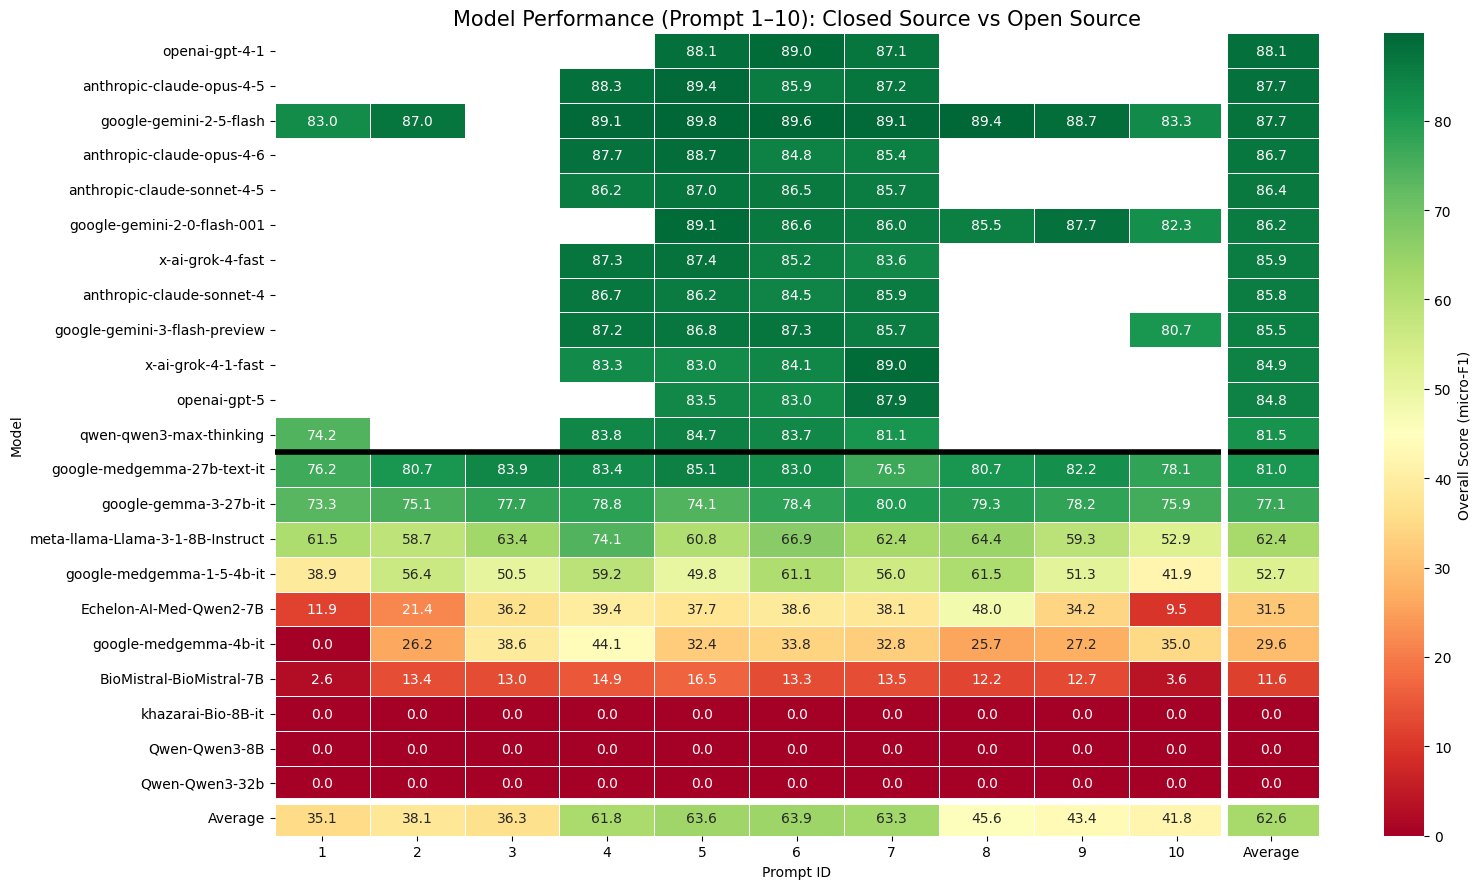

In [9]:
# Plot heatmap
n_closed = len(closed_sorted)
plt.figure(figsize=(16, max(9, (len(closed_sorted) + len(open_sorted)) * 0.25)))
ax = sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Overall Score (micro-F1)'},
)

# Black thick line separating closed source from open source models
ax.axhline(y=n_closed, color='black', linewidth=4)

# White line separating the Average column from prompt columns
ax.axvline(x=pivot_df.shape[1] - 1, color='white', linewidth=5)

# White line separating the Average row from model rows
ax.axhline(y=pivot_df.shape[0] - 1, color='white', linewidth=5)

plt.title('Model Performance (Prompt 1–10): Closed Source vs Open Source', fontsize=15)
plt.ylabel('Model')
plt.xlabel('Prompt ID')
plt.tight_layout()
plt.savefig('subtask4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
